In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib

from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import classification_report, roc_auc_score

from src.data_loader         import load_raw_data, basic_profiling
from src.feature_engineering import build_viralidad, build_features, get_feature_columns
from src.preprocessing       import build_preprocessor, split_data, save_preprocessor

# IMPORTACIONES ACTUALIZADAS
from src.modeling            import get_base_models, tune_hyperparameters, cross_validate_models, train_and_save
from src.evaluation          import (
    evaluate_on_test, plot_confusion_matrices, plot_roc_curves,
    plot_feature_importance, plot_cv_comparison, plot_metrics_heatmap, save_tuning_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000
RAW_PATH     = '../data/raw/global_youtube_creator_data_large.csv'
FIGURES_DIR  = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


In [2]:
import os, pickle
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(''))
while PROJECT_ROOT.name != 'Proyecto_Final_ML':
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
print("Working dir:", PROJECT_ROOT)

# Cargar artefactos de Fase 3
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase3_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

X_train_proc       = artifacts['X_train_proc']
X_test_proc        = artifacts['X_test_proc']
y_train            = artifacts['y_train']
y_test             = artifacts['y_test']
df                 = artifacts['df_clean']
feature_names_proc = artifacts['feature_names_proc']

print("Artefactos de Fase 3 cargados")

Working dir: c:\Users\jespi\OneDrive - Universidad de la Sabana\PoyectoML\Proyecto_Final_ML
Artefactos de Fase 3 cargados


---
# FASE 4 | MODELADO (Modeling)
---

## 4.1 Descripción de modelos

### Regresión Logística
Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la funcion sigmoide. Sirve como **modelo de referencia (baseline)** por su simplicidad e interpretabilidad. Requiere que las variables esten escaladas (StandardScaler ya aplicado).

### Random Forest
Ensamble de arboles de decision entrenados con *bootstrap* sobre subconjuntos aleatorios de datos y caracteristicas (*bagging*). La prediccion final es el voto mayoritario. Robusto al ruido, maneja bien relaciones no lineales y provee importancia de caracteristicas.

### Gradient Boosting
Ensamble secuencial donde cada arbol corrige los errores del anterior minimizando una funcion de perdida mediante descenso de gradiente. `learning_rate` bajo (0.05) con `n_estimators` alto (200) equilibra bias-varianza. `subsample=0.8` agrega estocasticidad para mayor regularizacion.

## 4.2 Validacion cruzada estratificada (5-fold)

**StratifiedKFold** garantiza que cada fold tenga la misma proporcion de clases que el conjunto completo. Se reportan media y desviacion estandar de cada metrica para evaluar estabilidad del modelo.

In [3]:
# Instanciar modelos base
base_models = get_base_models(random_state=RANDOM_STATE)

print('Iniciando búsqueda de hiperparámetros (RandomizedSearchCV)...')
print('Nota: Esto puede tomar unos minutos dependiendo de los recursos del sistema.\n')

# Ejecutar el tuning
best_models = tune_hyperparameters(
    base_models, X_train_proc, y_train.values,
    n_iter=15, cv_folds=3, random_state=RANDOM_STATE
)

# Guardar el reporte de los mejores hiperparámetros en disco
save_tuning_report(best_models, save_path='../reports/best_hyperparameters.json')

Iniciando búsqueda de hiperparámetros (RandomizedSearchCV)...
Nota: Esto puede tomar unos minutos dependiendo de los recursos del sistema.


[TUNING] Iniciando busqueda para: Regresion Logistica


Fitting 3 folds for each of 15 candidates, totalling 45 fits
    Mejor ROC-AUC (CV): 0.6634
    Mejores params: {'C': np.float64(0.0010090061869151559), 'class_weight': 'balanced'}
    Tiempo de busqueda: 18.7s

[TUNING] Iniciando busqueda para: Random Forest
Fitting 3 folds for each of 15 candidates, totalling 45 fits
    Mejor ROC-AUC (CV): 0.6762
    Mejores params: {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
    Tiempo de busqueda: 159.7s

[TUNING] Iniciando busqueda para: Gradient Boosting
Fitting 3 folds for each of 15 candidates, totalling 45 fits
    Mejor ROC-AUC (CV): 0.6795
    Mejores params: {'learning_rate': np.float64(0.019970999139010043), 'max_depth': 6, 'n_estimators': 210, 'subsample': np.float64(0.9049790556476374)}
    Tiempo de busqueda: 794.2s

[INFO] Reporte de hiperparametros guardado en: ../reports/best_hyperparameters.json


In [4]:
print('\nIniciando validación cruzada estratificada (5-fold) sobre los modelos OPTIMIZADOS...')

cv_results = cross_validate_models(
    best_models, X_train_proc, y_train.values,
    cv_folds=5, random_state=RANDOM_STATE
)


Iniciando validación cruzada estratificada (5-fold) sobre los modelos OPTIMIZADOS...

[CV] Validando modelo optimizado: Regresion Logistica (5 folds)...
    F1       : 0.6127 ± 0.0031
    ROC-AUC  : 0.6634 ± 0.0040

[CV] Validando modelo optimizado: Random Forest (5 folds)...
    F1       : 0.6579 ± 0.0037
    ROC-AUC  : 0.6767 ± 0.0051

[CV] Validando modelo optimizado: Gradient Boosting (5 folds)...
    F1       : 0.6562 ± 0.0025
    ROC-AUC  : 0.6799 ± 0.0044


In [5]:
print('\nResumen de Validacion Cruzada:')
cols_show = ['ROC-AUC (val)', 'ROC-AUC std', 'F1 (val)', 'F1 std',
             'Accuracy (val)', 'Accuracy std', 'Precision (val)', 'Recall (val)',
             'Accuracy (train)', 'Tiempo (s)']
display(cv_results[cols_show].round(4))


Resumen de Validacion Cruzada:


,ROC-AUC (val),ROC-AUC std,F1 (val),F1 std,Accuracy (val),Accuracy std,Precision (val),Recall (val),Accuracy (train),Tiempo (s)
Regresion Logistica,0.6634,0.0040,0.6127,0.0031,0.6123,0.0047,0.6122,0.6133,0.6131,0.5
Random Forest,0.6767,0.0051,0.6579,0.0037,0.6214,0.0054,0.6001,0.7280,0.7838,18.6
Gradient Boosting,0.6799,0.0044,0.6562,0.0025,0.6233,0.0047,0.6036,0.7189,0.6396,145.6


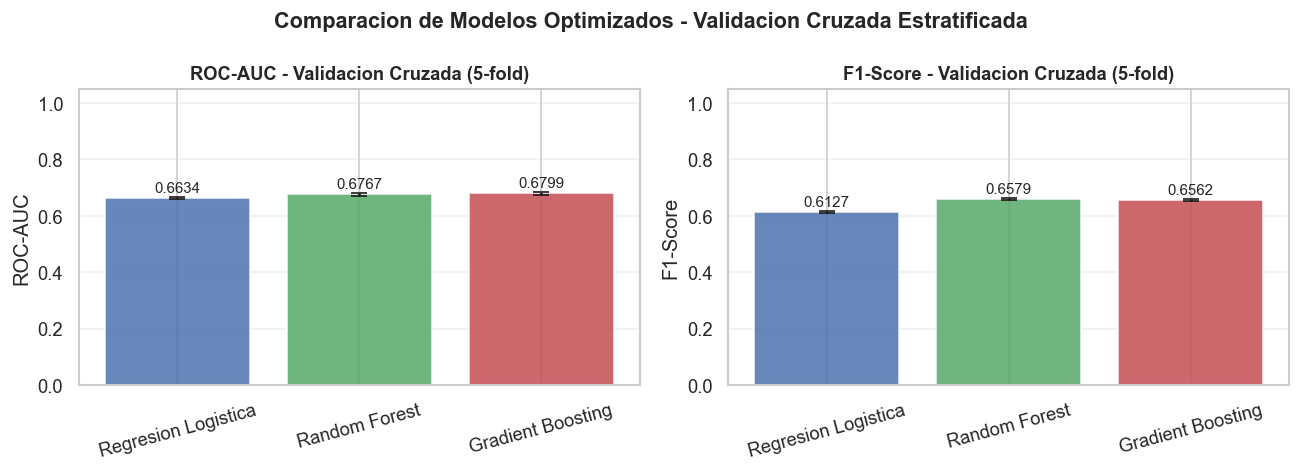

[INFO] Figura guardada: ../reports/figures/cv_comparison.png


In [6]:
plot_cv_comparison(cv_results, save_path=f'{FIGURES_DIR}/cv_comparison.png')

## 4.3 Analisis de sobreajuste (overfitting)

La diferencia entre `Accuracy (train)` y `Accuracy (val)` en la validacion cruzada indica el grado de sobreajuste.

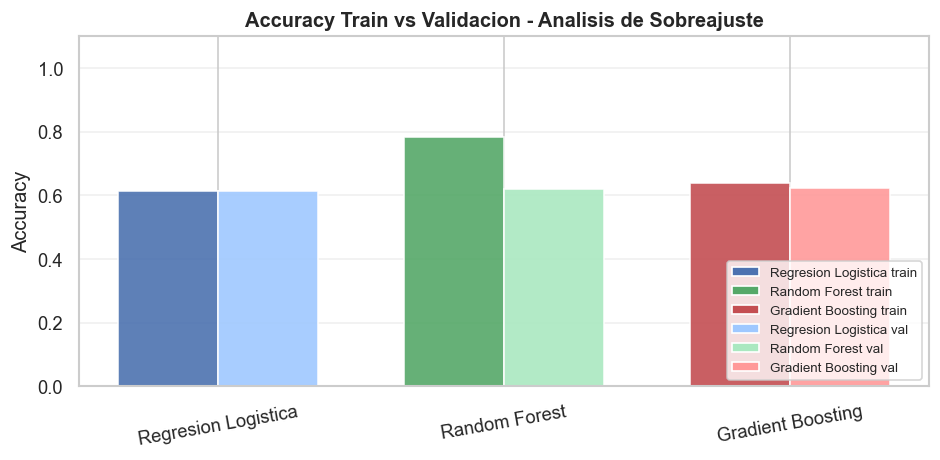


Diferencia Train - Val (indica sobreajuste):
  Regresion Logistica      : +0.0008
  Random Forest            : +0.1624
  Gradient Boosting        : +0.0163


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(cv_results))
w = 0.35
colors_train = ['#4C72B0', '#55A868', '#C44E52']
colors_val   = ['#9FC8FF', '#AAE8C0', '#FF9999']

for i, (name, row) in enumerate(cv_results.iterrows()):
    ax.bar(x[i] - w/2, row['Accuracy (train)'], w, label=f'{name} (train)' if i==0 else '',
           color=colors_train[i], alpha=0.9)
    ax.bar(x[i] + w/2, row['Accuracy (val)'],   w, label=f'{name} (val)' if i==0 else '',
           color=colors_val[i],   alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cv_results.index, rotation=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_title('Accuracy Train vs Validacion - Analisis de Sobreajuste', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_train[i], label=f'{name} train') for i, name in enumerate(cv_results.index)]
legend_elements += [Patch(facecolor=colors_val[i], label=f'{name} val') for i, name in enumerate(cv_results.index)]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/overfitting_analysis.png', bbox_inches='tight')
plt.show()

print('\nDiferencia Train - Val (indica sobreajuste):')
for name, row in cv_results.iterrows():
    diff = row['Accuracy (train)'] - row['Accuracy (val)']
    print(f'  {name:25}: {diff:+.4f}')

## 4.4 Entrenamiento final sobre todo el conjunto de entrenamiento

In [8]:
trained_models = {}
for name, model in best_models.items():
    trained_models[name] = train_and_save(
        model, name, X_train_proc, y_train.values,
        models_dir=str(PROJECT_ROOT / 'models')
    )

[INFO] Entrenando modelo final Regresion Logistica...
[INFO] Regresion Logistica entrenado en 1.1s -> guardado en c:\Users\jespi\OneDrive - Universidad de la Sabana\PoyectoML\Proyecto_Final_ML\models\regresion_logistica.joblib
[INFO] Entrenando modelo final Random Forest...
[INFO] Random Forest entrenado en 3.8s -> guardado en c:\Users\jespi\OneDrive - Universidad de la Sabana\PoyectoML\Proyecto_Final_ML\models\random_forest.joblib
[INFO] Entrenando modelo final Gradient Boosting...
[INFO] Gradient Boosting entrenado en 125.1s -> guardado en c:\Users\jespi\OneDrive - Universidad de la Sabana\PoyectoML\Proyecto_Final_ML\models\gradient_boosting.joblib


In [10]:
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase4_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'trained_models': trained_models,
        'best_models':    best_models,
        'cv_results':     cv_results 
    }, f)

print("Guardado en:", PROJECT_ROOT / 'data' / 'processed' / 'fase4_artifacts.pkl')

Guardado en: c:\Users\jespi\OneDrive - Universidad de la Sabana\PoyectoML\Proyecto_Final_ML\data\processed\fase4_artifacts.pkl
